In [1]:
import pandas as pd
df = pd.read_csv('df_dml.csv',sep=',')
df.head()

,id,time,x_1,x_2,t,y
0,0,0,-0.423760,0.499735,0.829720,5.864014
1,0,1,-0.453414,-0.427674,1.304880,10.705622
2,0,2,-1.795643,0.247127,6.176610,199.313617
3,0,3,-0.330090,-1.455368,-0.229623,-0.914282
4,0,4,0.732829,2.274512,11.006685,627.991147


In [2]:
import statsmodels.formula.api as smf

# Наивная OLS с контролем x_1 и x_2 но без FE и нелинейности
naive_ols = smf.ols('y ~ t + x_1 + x_2', data=df).fit()
ate_naive = naive_ols.params['t']
print('Наивная OLS:', round(ate_naive, 1))

Наивная OLS: 41.1


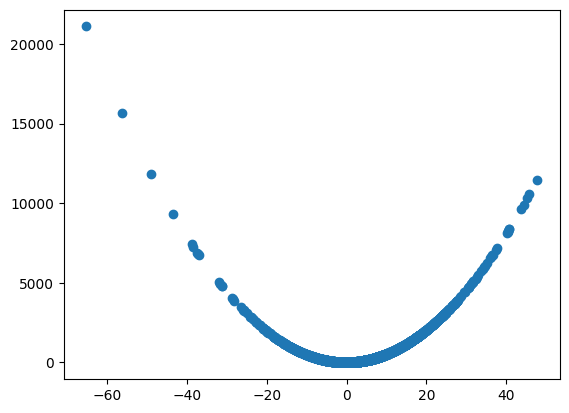

In [3]:
import matplotlib.pyplot as plt
plt.scatter(df['t'], df['y'])
plt.show()

In [4]:
# Шаг 1: линеаризация воздействия (возводим t в квадрат)
df['t_sq'] = df['t'] ** 2

# Шаг 2: demeaning для линеаризованного воздействия и результата
for col in ['t_sq', 'y', 'x_1', 'x_2']:
    df[f'{col}_mean_id'] = df.groupby('id')[col].transform('mean')
    df[f'{col}_mean_time'] = df.groupby('time')[col].transform('mean')
    df[f'{col}_dm'] = df[col] - df[f'{col}_mean_id'] - df[f'{col}_mean_time']

# Среднее demeaned колонки воздействия
print(round(df['t_sq_dm'].mean(), 1))

-24.8


In [5]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Сортируем по времени
df = df.sort_values('time')

# Сетка гиперпараметров
param_grid = {
    'criterion': ['squared_error', 'friedman_mse'],
    'max_depth': [12, 15, 18, 22],
    'min_samples_leaf': [1, 2, 3, 5],
    'min_samples_split': [2, 5, 10],
    'max_features': [None, 0.8],
    'ccp_alpha': [0.0, 1e-4, 1e-3]
}

tss = TimeSeriesSplit(n_splits=5)
features = ['x_1_dm', 'x_2_dm']

# Debias model (предсказываем t_sq_dm по конфаундерам)
debias_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=tss,
    n_jobs=-1
)
debias_gs.fit(df[features], df['t_sq_dm'])
debias_model = debias_gs.best_estimator_
print('Debias лучшие параметры:', debias_gs.best_params_)

# Denoise model (предсказываем y_dm по конфаундерам)
denoise_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=tss,
    n_jobs=-1
)
denoise_gs.fit(df[features], df['y_dm'])
denoise_model = denoise_gs.best_estimator_
print('Denoise лучшие параметры:', denoise_gs.best_params_)


Debias лучшие параметры: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 12, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Denoise лучшие параметры: {'ccp_alpha': 0.001, 'criterion': 'squared_error', 'max_depth': 12, 'max_features': 0.8, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [7]:
from sklearn.model_selection import cross_val_predict
import statsmodels.formula.api as smf

# Шаг 1: out-of-fold предсказания для воздействия
t_pred = cross_val_predict(debias_model, df[features], df['t_sq_dm'], cv=tss)

# Шаг 2: out-of-fold предсказания для результата
y_pred = cross_val_predict(denoise_model, df[features], df['y_dm'], cv=tss)

# Шаг 3: получаем остатки
df['t_resid'] = df['t_sq_dm'] - t_pred
df['y_resid'] = df['y_dm'] - y_pred

# Шаг 4: OLS на остатках с кластеризованными ошибками
dml_model = smf.ols('y_resid ~ t_resid', data=df).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['id']}
)

ate_dml = dml_model.params['t_resid']
print('DML оценка ATE:', round(ate_dml, 1))
print('Истинный ATE:', 5.0)


ValueError: cross_val_predict only works for partitions

In [9]:
from sklearn.model_selection import cross_val_predict
import statsmodels.formula.api as smf

features = ['x_1_dm', 'x_2_dm']

# Шаг 1: out-of-fold предсказания для воздействия
t_pred = cross_val_predict(debias_model, df[features], df['t_sq_dm'], cv=5)

# Шаг 2: out-of-fold предсказания для результата
y_pred = cross_val_predict(denoise_model, df[features], df['y_dm'], cv=5)

# Шаг 3: остатки
df['t_resid'] = df['t_sq_dm'] - t_pred
df['y_resid'] = df['y_dm'] - y_pred

# Шаг 4: OLS на остатках
dml_model = smf.ols('y_resid ~ t_resid', data=df).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['id']}
)

print('DML оценка ATE:', round(dml_model.params['t_resid'], 1))
print('Истинный ATE:', 5.0)

DML оценка ATE: 4.7
Истинный ATE: 5.0
